# Fitting the simulation to the data

This notebook shows how simulation-derived universalization metrics and
scenario outcome metrics relate to average moral judgments, following the
regression approach used in Kwon et al. (CogSci 2023).

It is provided as an illustrative analysis for readers, not as the primary
statistical analysis for the new paper.

In [1]:
import pandas as pd
from build_utils import get_universalization_summary, get_outcome_metrics, build_design_matrix
from analysis_utils import plot_simple_regression, compare_models, fit_ols

# Simulation run to use
RUN_LABEL = "paper_data"

# Columns used in analyses
OUTCOME_COLS = ["aggregate_welfare", "inequality", "cardinal_harm", "ordinal_harm_blind", "gini"]
UNIV_COLS = [f"univ_{c}" for c in OUTCOME_COLS]

## 1. Data loading and design matrix

We load:

- scenario-level outcome metrics (computed from scenario completion times),
- experimental judgments (`cross_cultural_pilot_summary.csv`),
- universalization metrics for the simulation run `RUN_LABEL`,

and combine them into a regression-ready design matrix.

In [2]:
# Outcome metrics
out = get_outcome_metrics(recompute=False) # set to True to rebuild from completion times

# Experimental judgments
xp_file = "cross_cultural_pilot_summary.csv"
xp = pd.read_csv(f"../data/experimental/{xp_file}")

# Universalization summary for this simulation run
univ = get_universalization_summary(run_label=RUN_LABEL, recompute=False) # set to True to rebuild from raw simulation data

# Regression-ready design matrix: one row per scenario
design = build_design_matrix(univ, out, xp)

## 2. Outcome-only models

We first ask: among the outcome metrics derived directly from the line-cutting
scenarios, which combination best predicts average moral judgments?

We fit OLS models for all non-empty subsets of the outcome metrics and compare
them using BIC (and R², adjusted R²).

*Result (for this dataset):* the best outcome-only model is a simple regression
on **aggregate_welfare**.

In [3]:
summary_baseline = compare_models(
    design_df=design,
    predictors=OUTCOME_COLS,
    run_label=RUN_LABEL,
    dv="rating_mean"
)
summary_baseline.head() # Show best models sorted by BIC

,n_predictors,predictors,run_label,R2,adj_R2,AIC,BIC,n,predictors_full_name
0,1,AW,paper_data,0.629469,0.619455,61.299306,64.626429,39,aggregate_welfare
7,2,AW+OH,paper_data,0.636171,0.615958,62.587446,67.578131,39,aggregate_welfare+ordinal_harm_blind
5,2,AW+Ineq,paper_data,0.630512,0.609985,63.189425,68.180110,39,aggregate_welfare+inequality
8,2,AW+Gini,paper_data,0.629938,0.609379,63.249888,68.240573,39,aggregate_welfare+gini
6,2,AW+CH,paper_data,0.629642,0.609067,63.281087,68.271772,39,aggregate_welfare+cardinal_harm


## 3. Adding universalization metrics from the simulation

Next, we test whether **universalization metrics** computed from the simulation
help explain additional variance in moral judgments.

We start from the baseline model with aggregate welfare (shown above to be the
best outcome-only model) and consider models that add one or more
universalization metrics.

*Result (for this dataset):*

- the best model uses one simulation-based predictor: **univ_aggregate_welfare**
  in addition to aggregate_welfare;
- compared to the aggregate-welfare-only baseline, this model shows a decrease
  in BIC of about 7 and an increase in R² of about 0.09.

In [4]:
summary_univ = compare_models(
    design_df=design,
    predictors=["aggregate_welfare"] + UNIV_COLS,
    run_label=RUN_LABEL,
    dv="rating_mean",
)
summary_univ.head() # Show best models sorted by BIC

,n_predictors,predictors,run_label,R2,adj_R2,AIC,BIC,n,predictors_full_name
6,2,AW+U_AW,paper_data,0.719545,0.703964,52.436906,57.427591,39,aggregate_welfare+univ_aggregate_welfare
22,3,AW+U_AW+U_CH,paper_data,0.735472,0.712798,52.156742,58.810989,39,aggregate_welfare+univ_aggregate_welfare+univ_...
21,3,AW+U_AW+U_Ineq,paper_data,0.734975,0.712259,52.229911,58.884158,39,aggregate_welfare+univ_aggregate_welfare+univ_...
24,3,AW+U_AW+U_Gini,paper_data,0.731153,0.708109,52.788375,59.442622,39,aggregate_welfare+univ_aggregate_welfare+univ_...
8,2,AW+U_CH,paper_data,0.698281,0.681519,55.287116,60.277801,39,aggregate_welfare+univ_cardinal_harm


## 4. Visualizations

We visualize three relationships:

1. Judgments vs Aggregate Welfare (baseline model).
2. Judgments vs Universalized Aggregate Welfare.
3. Judgments vs predictions from the full model (AW + U_AW).

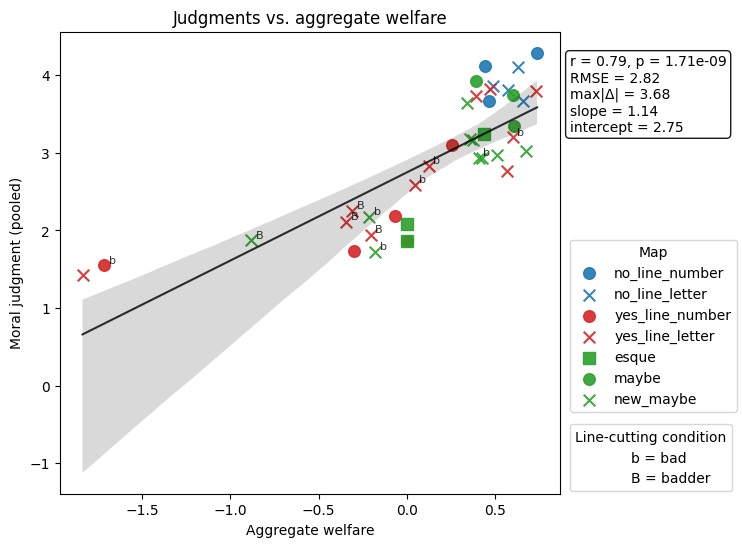

In [8]:
# Ratings vs AW
fig, ax = plot_simple_regression(
    design,
    x_col="aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Judgments vs. aggregate welfare",
    xlabel="Aggregate welfare",
    ylabel="Moral judgment (pooled)",
    display_line_cutting_condition=True,
    fit_regression=True,
)

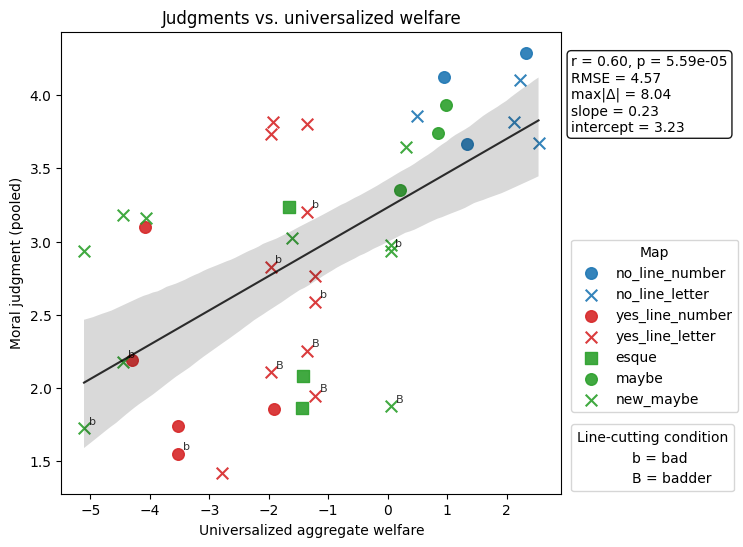

In [6]:
# Ratings vs universalized AW
fig, ax = plot_simple_regression(
    design,
    x_col="univ_aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Judgments vs. universalized welfare",
    xlabel="Universalized aggregate welfare",
    ylabel="Moral judgment (pooled)",
    display_line_cutting_condition=True,
    fit_regression=True,
)

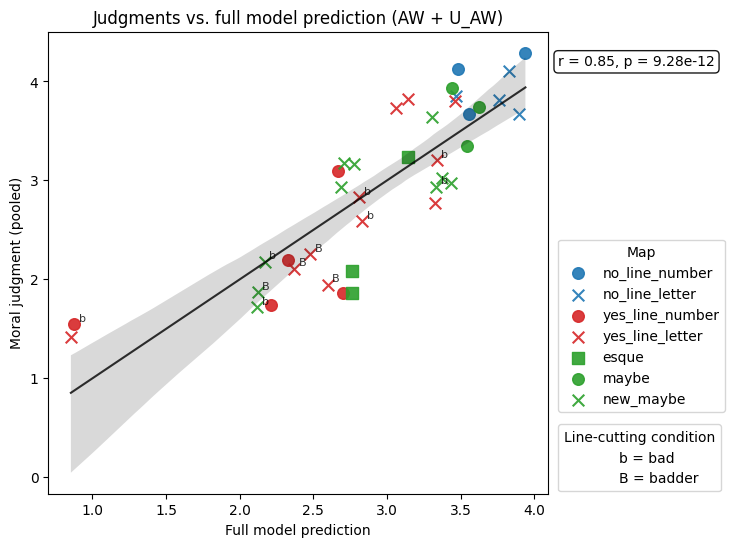

In [9]:
# Full model
row_full, m_full = fit_ols(
    design_df=design,
    predictors=["aggregate_welfare", "univ_aggregate_welfare"],
    dv="rating_mean",
    run_label=RUN_LABEL,
)
design["full_model"] = m_full.fittedvalues


# Ratings vs full model prediction (AW + U_AW)
fig, ax = plot_simple_regression(
    design,
    x_col="full_model",
    y_col="rating_mean",
    map_col="map_name",
    title="Judgments vs. full model prediction (AW + U_AW)",
    xlabel="Full model prediction",
    ylabel="Moral judgment (pooled)",
    display_line_cutting_condition=True,
    fit_regression=False,  # just correlation line
)